# Aufgabe 3

In [97]:
import matplotlib.pyplot as plt
import numpy as np
from skimage.io import imread
from skimage.filters import gaussian
from skimage.util import random_noise

In [98]:
img_original = imread("einstein.png")

## 3.1
Original Bild und mit Gaussian Noise (var=0.01) vergleichen.

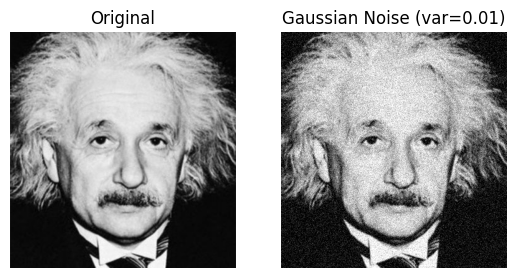

In [99]:
img_norm = img_original / 255

img_noise = random_noise(img_norm, mode="gaussian", var=0.01)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(img_original, cmap="grey")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(img_noise, cmap="grey")
axs[1].set_title("Gaussian Noise (var=0.01)")
axs[1].axis("off")

plt.show()

## 3.2 
Funktion, die den mittleren absoluten Unterschied zwischen den korrespondierenden Pixeln zweier Bilder berechnet.

In [100]:
def mean_abs_diff(img_1: np.ndarray, img_2: np.ndarray) -> float:
    """Calculates and returns the mean absolute difference between two given images."""

    abs_diff_per_pixel = np.abs(img_1 - img_2)
    mean_abs_diff = np.mean(abs_diff_per_pixel)

    return mean_abs_diff

In [101]:
print(f"Die mittlere absolute Differenz der Bilder beträgt: {mean_abs_diff(img_norm, img_noise)}")

Die mittlere absolute Differenz der Bilder beträgt: 0.0725305665835193


## 3.3
Beste Standabweichung für Gauss-Filter finden und bestes Ergebnis darstellen.

In [102]:
def eval_best_std(std_range: np.arange, img) -> tuple:
    """Evaluate the best standard deviation in a given range for the gaussian filter apllied to a given image."""
    best_std = None
    best_diff = None
    best_img_filtered = None

    for std in std_range:
        img_filtered = gaussian(img, sigma=std, mode="nearest")
        ma_diff = mean_abs_diff(img_norm, img_filtered)

        if best_img_filtered is None:
            best_std = std
            best_diff = ma_diff
            best_img_filtered = img_filtered

        elif ma_diff < best_diff:
            best_std = std
            best_diff = ma_diff
            best_img_filtered = img_filtered
    
    return best_std, best_diff, best_img_filtered

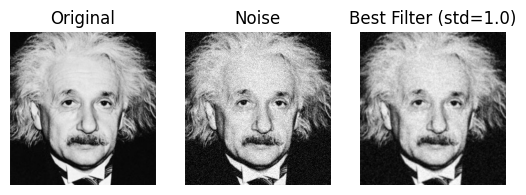

Geringste mittlere Distanz zum Originalbild: 0.029684795191831086


In [103]:
std_range = np.arange(0.1, 2.1, 0.1)
best_std, best_diff, best_img_filtered = eval_best_std(std_range, img_noise)

fix, axs = plt.subplots(1, 3)
axs[0].imshow(img_original, cmap="grey")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(img_noise, cmap="grey")
axs[1].set_title("Noise")
axs[1].axis("off")

axs[2].imshow(best_img_filtered, cmap="grey")
axs[2].set_title(f"Best Filter (std={best_std})")
axs[2].axis("off")

plt.show()

print(f"Geringste mittlere Distanz zum Originalbild: {best_diff}")

## 3.4 & 3.5
Salt and Pepper Noise, Gauss-Filter mit verschiedenen Standardabweichungen, bestes Ergebnis visualisieren.

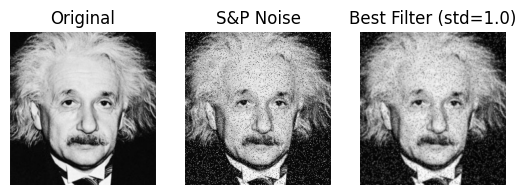

Mittlere absolute Differenz Original zu S&P Noise Bild: 0.05044839046246308

Geringste mittlere Distanz zum Originalbild nach Filter: 0.04710844560629983


In [104]:
img_sp_noise = random_noise(img_norm, mode="s&p", amount=0.1)

std_range = np.arange(0.1, 2.1, 0.1)
best_std, best_diff, best_img_filtered = eval_best_std(std_range, img_sp_noise)

fix, axs = plt.subplots(1, 3)
axs[0].imshow(img_original, cmap="grey")
axs[0].set_title("Original")
axs[0].axis("off")

axs[1].imshow(img_sp_noise, cmap="grey")
axs[1].set_title("S&P Noise")
axs[1].axis("off")

axs[2].imshow(best_img_filtered, cmap="grey")
axs[2].set_title(f"Best Filter (std={best_std})")
axs[2].axis("off")

plt.show()

print(f"Mittlere absolute Differenz Original zu S&P Noise Bild: {mean_abs_diff(img_norm, img_sp_noise)}\n")
print(f"Geringste mittlere Distanz zum Originalbild nach Filter: {best_diff}")

Die mittlere Distanz zum Original wird nach Anwendung des besten Filters auf das Bild mit S&P Noise nur geringfügig besser. Der Gaussfilter funktioniert bei der Anwendung auf das Bild mit gaussian_noise deutlich besser.